<a href="https://colab.research.google.com/github/dilekmirac/goruntu_isleme/blob/main/hafta2_g%C3%B6rev5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import torch

print(f"OpenCV Versiyonu: {cv2.__version__}")
print(f"CUDA Kullanılabilir mi (PyTorch/GPU): {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Aktif GPU Modeli: {torch.cuda.get_device_name(0)}")

OpenCV Versiyonu: 5.0.0
CUDA Kullanılabilir mi (PyTorch/GPU): True
Aktif GPU Modeli: Tesla T4


       (p * 0.75 + 20) ZAMAN VE PERFORMANS RAPORU
Tek Çekirdek Süresi       : 4.5554 saniye
4 Çekirdek Paralel Süresi : 4.5935 saniye
Hızlanma Oranı (Speedup)  : 0.99 kat daha hızlı!


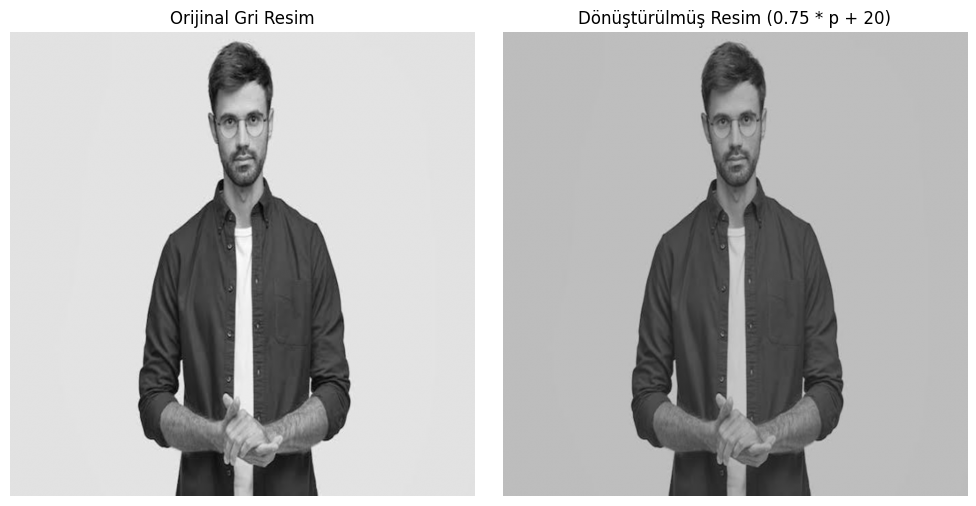

In [ ]:
import cv2
import numpy as np
import time
from multiprocessing import Pool
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. Her bir çekirdeğin çalıştıracağı işlem fonksiyonu
# -------------------------------------------------------------------------
def piksel_donustur(roi):
    """
    Kendisine gelen ROI parçasındaki her bir piksel için:
    yeni_deger = (piksel * 0.75) + 20
    işlemini yapar ve 0-255 sınırında tutar.
    """
    h, w = roi.shape
    islenmis_roi = np.zeros((h, w), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            p = float(roi[i, j])

            # Formül: 0.75 ile çarp + 20 ekle
            yeni_p = int(p * 0.75 + 20)

            # Değerin 0 ile 255 arasında kalmasını sağla (taşma kontrolü)
            if yeni_p > 255:
                yeni_p = 255
            elif yeni_p < 0:
                yeni_p = 0

            islenmis_roi[i, j] = yeni_p

    return islenmis_roi

# -------------------------------------------------------------------------
# 2. Ana Çalışma Bloğu
# -------------------------------------------------------------------------
if __name__ == '__main__':
    img_bgr = cv2.imread('insan.jpg')
    if img_bgr is None:
        raise FileNotFoundError("'insan.jpg' bulunamadı! Lütfen sol panele görseli yükleyin.")

    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 2 - 2.5 kat hızlanmayı net görebilmek için boyutu koruyoruz/büyütüyoruz
    img_gray = cv2.resize(img_gray, (3000, 3000))
    h, w = img_gray.shape

    # Resmi 4 eşit ROI parçasına böl
    orta_y, orta_x = h // 2, w // 2
    roiler = [
        img_gray[0:orta_y, 0:orta_x],          # Sol-Üst
        img_gray[0:orta_y, orta_x:w],          # Sağ-Üst
        img_gray[orta_y:h, 0:orta_x],          # Sol-Alt
        img_gray[orta_y:h, orta_x:w]           # Sağ-Alt
    ]

    # ---------------------------------------------------------------------
    # DENEY 1: Tek Çekirdekle Sıralı İşleme
    # ---------------------------------------------------------------------
    basla_tek = time.perf_counter()
    sonuclar_tek = [piksel_donustur(r) for r in roiler]
    bitir_tek = time.perf_counter()
    sure_tek = bitir_tek - basla_tek

    # ---------------------------------------------------------------------
    # DENEY 2: 4 Çekirdekle Paralel İşleme
    # ---------------------------------------------------------------------
    basla_paralel = time.perf_counter()
    with Pool(processes=4) as pool:
        sonuclar_paralel = pool.map(piksel_donustur, roiler)
    bitir_paralel = time.perf_counter()
    sure_paralel = bitir_paralel - basla_paralel

    # ---------------------------------------------------------------------
    # Hızlanma Raporu
    # ---------------------------------------------------------------------
    hizlanma = sure_tek / sure_paralel if sure_paralel > 0 else 0
    print("=" * 50)
    print("       (p * 0.75 + 20) ZAMAN VE PERFORMANS RAPORU")
    print("=" * 50)
    print(f"Tek Çekirdek Süresi       : {sure_tek:.4f} saniye")
    print(f"4 Çekirdek Paralel Süresi : {sure_paralel:.4f} saniye")
    print(f"Hızlanma Oranı (Speedup)  : {hizlanma:.2f} kat daha hızlı!")
    print("=" * 50)

    # Parçaları birleştir
    ust = np.hstack((sonuclar_paralel[0], sonuclar_paralel[1]))
    alt = np.hstack((sonuclar_paralel[2], sonuclar_paralel[3]))
    nihai_resim = np.vstack((ust, alt))

    # Görselleştirme
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_gray, cmap='gray', vmin=0, vmax=255)
    plt.title("Orijinal Gri Resim")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(nihai_resim, cmap='gray', vmin=0, vmax=255)
    plt.title("Dönüştürülmüş Resim (0.75 * p + 20)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()